In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
df = pd.read_csv("customer_segmentation.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [5]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [6]:
df["Age"] = 2025 - df["Year_Birth"]
df["Children"] = df["Kidhome"] + df["Teenhome"]
df["Total_Spend"] = df[["MntWines","MntFruits","MntMeatProducts",
                        "MntFishProducts","MntSweetProducts","MntGoldProds"]].sum(axis=1)


In [7]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Children', 'Total_Spend'],
      dtype='object')

In [9]:
features = ["Income","Age","Children","Recency","Total_Spend",
            "NumWebPurchases","NumCatalogPurchases","NumStorePurchases","NumWebVisitsMonth"]
X = df[features]

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
inertias = []                          # elbow method
for k in range(2,11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

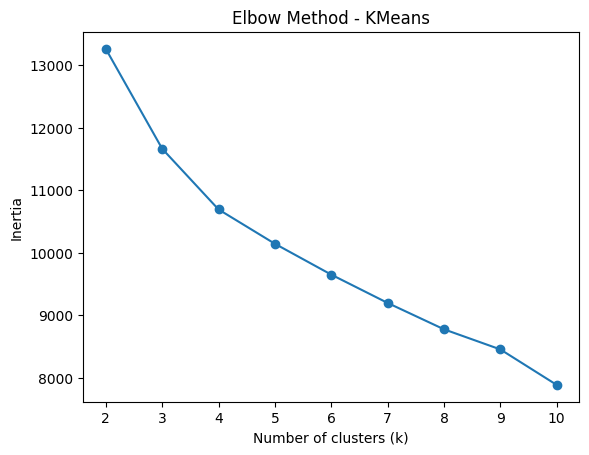

In [12]:
plt.plot(range(2,11), inertias, marker="o")
plt.title("Elbow Method - KMeans")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.show()

In [13]:
kmeans = KMeans(n_clusters=4, random_state=42)
df["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)
print("KMeans silhouette score:", silhouette_score(X_scaled, df["KMeans_Cluster"]))

KMeans silhouette score: 0.18269646261707473


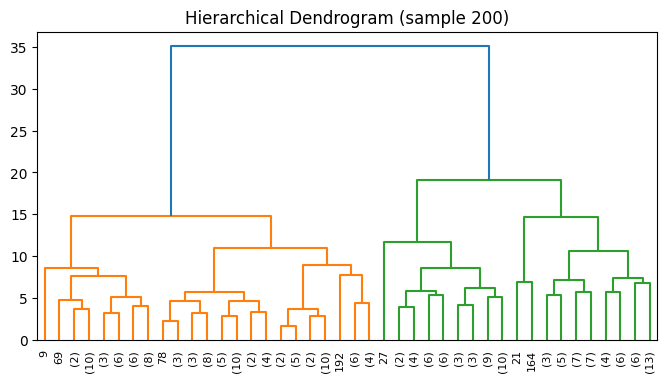

In [14]:
# Dendrogram
plt.figure(figsize=(8,4))
linked = linkage(X_scaled[:200], method='ward')  # sample 200 for visibility
dendrogram(linked, truncate_mode="level", p=5)
plt.title("Hierarchical Dendrogram (sample 200)")
plt.show()

In [15]:
# Fit Agglomerative with same number of clusters
agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
df["Hier_Cluster"] = agg.fit_predict(X_scaled)

print("Agglomerative silhouette score:", silhouette_score(X_scaled, df["Hier_Cluster"]))


Agglomerative silhouette score: 0.1544921365733046


In [16]:
print(df.groupby("KMeans_Cluster")[features].mean())

                      Income        Age  Children    Recency  Total_Spend  \
KMeans_Cluster                                                              
0               30001.643084  47.931638  0.837838  47.977742    98.906200   
1               61075.674797  59.234146  1.009756  46.460163   869.648780   
2               78652.537832  56.795501  0.112474  51.361963  1392.699387   
3               43628.008876  62.177515  1.826430  51.554241   155.644970   

                NumWebPurchases  NumCatalogPurchases  NumStorePurchases  \
KMeans_Cluster                                                            
0                      2.166932             0.516693           3.116057   
1                      6.998374             3.408130           8.221138   
2                      4.482618             6.335378           8.288344   
3                      2.546351             0.875740           3.749507   

                NumWebVisitsMonth  
KMeans_Cluster                     
0             

In [17]:
print(df.groupby("Hier_Cluster")[features].mean())

                    Income        Age  Children    Recency  Total_Spend  \
Hier_Cluster                                                              
0             78214.853061  56.922449  0.089796  50.712245  1408.822449   
1             31802.569048  50.177778  0.806349  50.096825    90.120635   
2             58403.899478  58.621410  1.125326  48.766319   754.992167   
3             39307.292373  60.641243  2.019774  45.875706    89.166667   

              NumWebPurchases  NumCatalogPurchases  NumStorePurchases  \
Hier_Cluster                                                            
0                    4.771429             6.206122           8.116327   
1                    1.941270             0.523810           3.084127   
2                    6.368146             3.140992           7.723238   
3                    2.008475             0.525424           3.203390   

              NumWebVisitsMonth  
Hier_Cluster                     
0                      2.532653  
1       